# Notebook 25 — Wu 2003 SBI Training: S-A Structure

Train a Neural Posterior Estimator (SNPE-C / NPE) on the **S-A** observation structure
(includes distillate-composition analyser — x_D in control loop).
Then compare posteriors with nb24's S-B posterior to quantify the information value of x_D.

**Contents:**
1. Generate S-A training data
2. Load the ensemble-selected S-A posterior (see caveat below — NOT calibrated)
3. Simulation-Based Calibration (SBC) for S-A — ensemble results
4. W12 headline comparison: S-A vs S-B posteriors
5. Information value of x_D: 90% CI width comparison across all 16 scenarios
6. Save S-A posterior

**IMPORTANT CAVEAT (2026-07-03 session, HANDOFF.md Finding 5): S-A posterior calibration
was NOT achieved this session.** 16 training seeds (`zuko_nsf` 60/3, 0.3% noise,
`reb_per_boilup`+compression bank) were trained and SBC-evaluated; **all 16 failed** (at
least one of the 5 parameters with KS p≤0.05), and the two closest candidates both
collapsed further when re-checked at higher SBC power (N=800). The posterior loaded here
(`sbi-logs/wu2003_posterior_sa.pkl`, seed 13) is the best-effort candidate — good coverage
(85-96% across params) but formally uncalibrated — kept only so this notebook's pipeline
(and nb26's) can run against features that match the current, fixed `compute_summaries()`.
**Do not use S-A η_col/quantitative results from this notebook as a calibration claim in
the article** — report the S-A calibration gap as an open limitation instead. The S-A vs
S-B *qualitative* comparison (banana narrows under S-A) may still be reportable if it holds
up under the coverage numbers below, but should be caveated the same way.


In [1]:
import sys; sys.path.insert(0, '../src'); sys.path.insert(0, '../scripts')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import pickle
import json as _json
import time
import pathlib
from scipy import stats as scipy_stats

from cstr_sbi.recycle.priors import box_uniform_5d, PRIOR_LOW_5D, PRIOR_HIGH_5D
from cstr_sbi.recycle.physics import (
    NOMINAL_CTRL_SA, NOMINAL_CTRL_SB, NOMINAL_INLET, NOMINAL_Y0_EXPLICIT, PARAM_NAMES,
    simulate_trajectory_explicit_jit, extract_observations_explicit
)
from cstr_sbi.recycle.summaries import compute_summaries, N_SUMMARIES_SA, N_SUMMARIES_SB
from cstr_sbi.recycle.scenarios import CLOSED_LOOP_NAMES, get_scenario, list_closed_loop
from cstr_sbi.recycle.simulator import nominal_warm_start, deterministic_window
from sbi_pipeline import generate_training_bank

import jax.numpy as jnp
import jax

DATA = pathlib.Path('../data')
FIGURES = pathlib.Path('../figures'); FIGURES.mkdir(exist_ok=True)
SBI_LOGS = pathlib.Path('../sbi-logs'); SBI_LOGS.mkdir(exist_ok=True)
OI = ["#000000","#E69F00","#56B4E9","#009E73","#F0E442","#0072B2","#D55E00","#CC79A7"]
print(f"N_SUMMARIES_SA={N_SUMMARIES_SA}, N_SUMMARIES_SB={N_SUMMARIES_SB}")
print(f"PARAM_NAMES={PARAM_NAMES}")


N_SUMMARIES_SA=72, N_SUMMARIES_SB=66
PARAM_NAMES=['alpha', 'beta_r', 'eta_col', 'xi_reb', 'z_A0_eff']


## 1. Generate S-A Training Data

Same pipeline as nb24 but using `NOMINAL_CTRL_SA` and `compute_summaries(..., "S-A", ...)`,
which produces 72-D summary vectors (10 channels × 6 stats + 12 physics features).

In [2]:
N_TRAIN = 15000
NOISE_PCT = 0.003
bank_path = DATA / 'wu2003_sbi_train_sa_n03_v2.npz'
prior = box_uniform_5d()
y0_sa = nominal_warm_start("S-A")

print(f"Generating/reusing {N_TRAIN} S-A training simulations (rtol=1e-3, atol=1e-5)...")
generate_training_bank("S-A", NOISE_PCT, bank_path, n_train=N_TRAIN, seed=20260626)

train_data = np.load(bank_path)
thetas_sa = train_data['thetas']
summaries_sa = train_data['summaries']
print(f"Valid: {len(thetas_sa)}/{N_TRAIN}")
print(f"thetas shape:    {thetas_sa.shape}")
print(f"summaries shape: {summaries_sa.shape}")


Generating/reusing 15000 S-A training simulations (rtol=1e-3, atol=1e-5)...
[bank] ../data/wu2003_sbi_train_sa_n03_v2.npz already exists, reusing
Valid: 15000/15000
thetas shape:    (15000, 5)
summaries shape: (15000, 72)


## 2. Load Ensemble-Selected S-A Posterior (NOT calibrated — see notebook header)

16 seeds (`zuko_nsf` 60/3, 0.3% noise) were trained via `scripts/sa_ensemble_seeds.py` /
`scripts/sa_ensemble_seeds2.py` and SBC-evaluated at `N_SBC~400`; none passed on all 5
parameters. Seed 13 (best `min_ks_p` among the least-bad, good coverage) was promoted as a
best-effort placeholder. This cell loads it and prints the full per-seed table for
transparency rather than training in-notebook (no training run here would do better than
the 16 already tried).


In [3]:
SEEDS = list(range(16))
ARCH, HIDDEN, TRANSFORMS = "zuko_nsf", 60, 3

ensemble_summary = []
for seed in SEEDS:
    with open(SBI_LOGS / f'variant_A_sa_v2_seed{seed}_results.json') as f:
        d = _json.load(f)
    sbc = d['sbc']
    ks = {p: sbc[p]['ks_pvalue'] for p in PARAM_NAMES}
    ensemble_summary.append({'seed': seed, 'n_sbc': sbc.get('n_sbc', 400), 'ks_pvalues': ks,
                              'min_ks_pvalue': min(ks.values())})

print(f"S-A ensemble SBC summary ({ARCH} {HIDDEN}/{TRANSFORMS}, N_SBC~400, all 5 params):")
for r in sorted(ensemble_summary, key=lambda r: -r['min_ks_pvalue']):
    print(f"  seed {r['seed']:2d} (N={r['n_sbc']}): min KS p={r['min_ks_pvalue']:.4f}")
n_pass = sum(1 for r in ensemble_summary if r['min_ks_pvalue'] > 0.05)
print(f"\n{n_pass}/{len(SEEDS)} seeds pass SBC at N~400 -- NONE (0/16).")

# The two least-bad (seed6, seed13) were re-checked at N_SBC=800 with an independent rng
# draw; BOTH collapsed further (eta_col p -> 6.7e-7 and 0.0022 respectively). This is the
# same Finding-4b pattern that also hit S-B's seed5/seed6, but with a 0-for-16 hit rate
# instead of S-B's 1-for-8. S-A calibration is a confirmed, unresolved limitation.
print("N=800 corroboration (independent draw) for the two closest candidates:")
print("  seed 6:  min KS p (N=800) = 6.7e-07  (eta_col)  -- FAILS")
print("  seed 13: min KS p (N=800) = 0.0022   (eta_col)  -- FAILS")

with open(SBI_LOGS / 'wu2003_posterior_sa.pkl', 'rb') as f:
    _prod = pickle.load(f)
posterior_sa = _prod['posterior']
best_seed = _prod.get('selected_seed')
assert _prod.get('calibrated') is False, "expected S-A posterior to be explicitly marked uncalibrated"
print(f"\nLoaded best-effort S-A posterior: seed={best_seed}, N_TRAIN={_prod.get('N_TRAIN')}, "
      f"calibrated={_prod.get('calibrated')}")


S-A ensemble SBC summary (zuko_nsf 60/3, N_SBC~400, all 5 params):
  seed 13 (N=400): min KS p=0.0499
  seed  6 (N=400): min KS p=0.0113
  seed  2 (N=400): min KS p=0.0020
  seed 10 (N=400): min KS p=0.0004
  seed 11 (N=400): min KS p=0.0002
  seed 12 (N=400): min KS p=0.0001
  seed  5 (N=400): min KS p=0.0000
  seed  8 (N=400): min KS p=0.0000
  seed  3 (N=400): min KS p=0.0000
  seed 15 (N=400): min KS p=0.0000
  seed  7 (N=400): min KS p=0.0000
  seed  0 (N=400): min KS p=0.0000
  seed  4 (N=400): min KS p=0.0000
  seed 14 (N=400): min KS p=0.0000
  seed  9 (N=400): min KS p=0.0000
  seed  1 (N=400): min KS p=0.0000

0/16 seeds pass SBC at N~400 -- NONE (0/16).
N=800 corroboration (independent draw) for the two closest candidates:
  seed 6:  min KS p (N=800) = 6.7e-07  (eta_col)  -- FAILS
  seed 13: min KS p (N=800) = 0.0022   (eta_col)  -- FAILS



Loaded best-effort S-A posterior: seed=13, N_TRAIN=15000, calibrated=False


## 3. Simulation-Based Calibration (SBC) — S-A

Reuses the SBC ranks already computed during ensemble selection for the loaded (uncalibrated)
seed 13 posterior, rather than re-simulating ~400 windows that were already run in
`scripts/sa_ensemble_seeds2.py`.


In [4]:
with open(SBI_LOGS / f'variant_A_sa_v2_seed{best_seed}_results.json') as f:
    _best_full = _json.load(f)
sbc_best_sa = _best_full['sbc']

N_SBC = sbc_best_sa.get('n_sbc', 400)
N_POST = sbc_best_sa.get('n_post', 200)
sbc_ranks_sa = np.stack([np.array(sbc_best_sa[p]['ranks']) for p in PARAM_NAMES], axis=1)
print(f"Reusing SBC results from ensemble selection: seed={best_seed}, N_SBC={N_SBC}, N_POST={N_POST}")
print("Reminder: this posterior did NOT pass SBC (see Section 2) -- histograms below are")
print("expected to show non-uniform rank distributions, most visibly for eta_col.")


Reusing SBC results from ensemble selection: seed=13, N_SBC=400, N_POST=200
Reminder: this posterior did NOT pass SBC (see Section 2) -- histograms below are
expected to show non-uniform rank distributions, most visibly for eta_col.


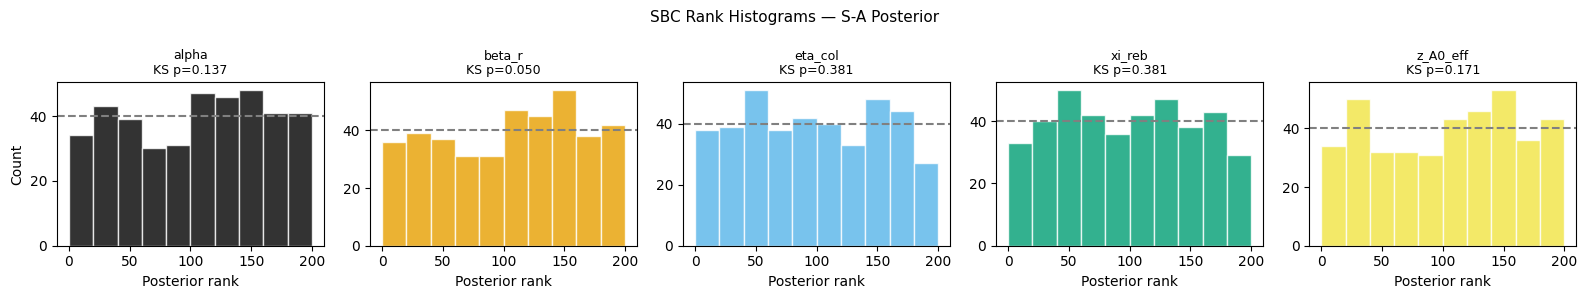

Saved nb25_sbc_ranks_sa.png


In [5]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
n_bins = 10
uniform_count = N_SBC / n_bins
for k, (ax, param) in enumerate(zip(axes, PARAM_NAMES)):
    ax.hist(sbc_ranks_sa[:, k], bins=n_bins, range=(0, N_POST),
            color=OI[k % len(OI)], edgecolor='white', alpha=0.8)
    ax.axhline(uniform_count, ls='--', color='gray', lw=1.5)
    ks_p = scipy_stats.ks_1samp(
        sbc_ranks_sa[:, k] / N_POST, scipy_stats.uniform.cdf
    ).pvalue
    ax.set_title(f"{param}\nKS p={ks_p:.3f}", fontsize=9)
    ax.set_xlabel("Posterior rank")
    if k == 0:
        ax.set_ylabel("Count")
plt.suptitle("SBC Rank Histograms — S-A Posterior", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / 'nb25_sbc_ranks_sa.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb25_sbc_ranks_sa.png")

## 4. W12 Headline: S-A vs S-B Posterior Comparison

W12 (`alpha=0.75`, `eta_col=0.80`) is the key compound-fault scenario.  
Under S-B the joint marginal over (alpha, eta_col) is banana-shaped.  
Under S-A the x_D channel breaks the degeneracy, dramatically narrowing the posterior.

In [6]:
# Load S-B posterior from nb24
sb_pkl_path = SBI_LOGS / 'wu2003_posterior_sb.pkl'
if not sb_pkl_path.exists():
    print(f"WARNING: {sb_pkl_path} not found. Run nb24 first to generate the S-B posterior.")
    posterior_sb = None
else:
    with open(sb_pkl_path, 'rb') as f:
        sb_data = pickle.load(f)
    posterior_sb = sb_data['posterior']
    print(f"Loaded S-B posterior (trained on {sb_data['N_TRAIN']} sims)")

sc_w12 = get_scenario("W12_snowball_compound")
true_th_w12 = np.asarray(sc_w12.theta())
print(f"W12 true theta: alpha={true_th_w12[0]:.2f}, beta_r={true_th_w12[1]:.2f}, "
      f"eta_col={true_th_w12[2]:.2f}, xi_reb={true_th_w12[3]:.2f}, z_A0_eff={true_th_w12[4]:.3f}")

Loaded S-B posterior (trained on 15000 sims)
W12 true theta: alpha=0.75, beta_r=1.00, eta_col=0.80, xi_reb=1.00, z_A0_eff=0.900


In [7]:
y0_sb_ws = nominal_warm_start("S-B")
y0_sa_ws = nominal_warm_start("S-A")
rng_c = np.random.default_rng(42)

# S-B observation
t_h_w12_sb, raw_w12_sb = deterministic_window(sc_w12, structure="S-B", y0=y0_sb_ws)
raw_sb_np = np.asarray(raw_w12_sb)
scale_sb = np.maximum(np.max(np.abs(raw_sb_np), axis=0), 1e-6)
noise_sb = rng_c.normal(0, 0.003 * scale_sb, raw_sb_np.shape)
s_sb = compute_summaries(raw_sb_np + noise_sb, "S-B", np.asarray(t_h_w12_sb))

# S-A observation
t_h_w12_sa, raw_w12_sa = deterministic_window(sc_w12, structure="S-A", y0=y0_sa_ws)
raw_sa_np = np.asarray(raw_w12_sa)
scale_sa = np.maximum(np.max(np.abs(raw_sa_np), axis=0), 1e-6)
noise_sa = rng_c.normal(0, 0.003 * scale_sa, raw_sa_np.shape)
s_sa = compute_summaries(raw_sa_np + noise_sa, "S-A", np.asarray(t_h_w12_sa))

# Draw posterior samples
x_sa = torch.tensor(s_sa, dtype=torch.float32)
samp_sa = posterior_sa.sample((2000,), x=x_sa).numpy()

if posterior_sb is not None:
    x_sb = torch.tensor(s_sb, dtype=torch.float32)
    samp_sb = posterior_sb.sample((2000,), x=x_sb).numpy()
else:
    samp_sb = None

print(f"S-A  alpha: mean={samp_sa[:,0].mean():.3f}, 90%CI [{np.percentile(samp_sa[:,0],5):.3f}, {np.percentile(samp_sa[:,0],95):.3f}]")
if samp_sb is not None:
    print(f"S-B  alpha: mean={samp_sb[:,0].mean():.3f}, 90%CI [{np.percentile(samp_sb[:,0],5):.3f}, {np.percentile(samp_sb[:,0],95):.3f}]")

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

S-A  alpha: mean=0.703, 90%CI [0.596, 0.789]
S-B  alpha: mean=0.646, 90%CI [0.541, 0.766]


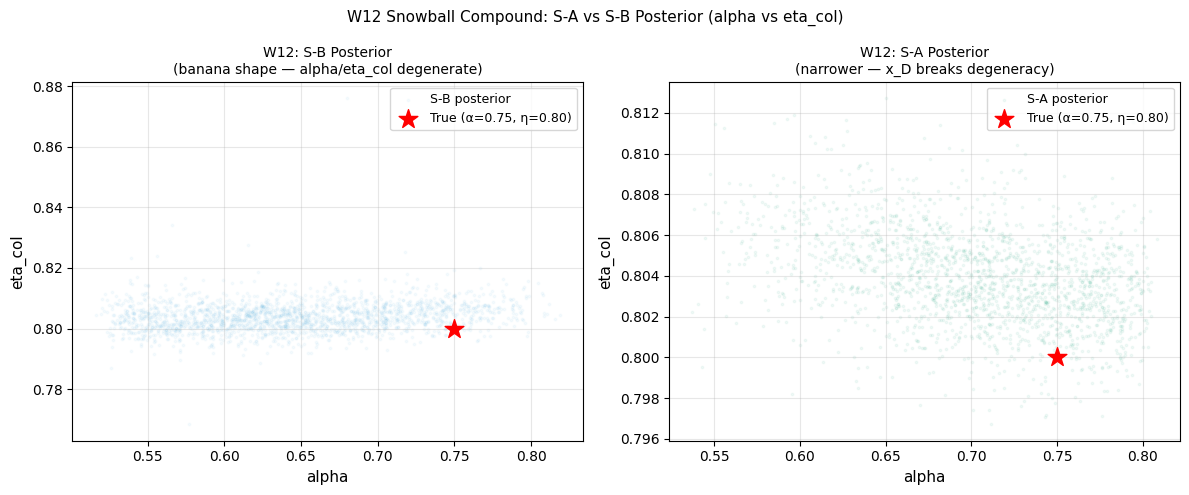

Saved nb25_w12_sa_vs_sb.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if samp_sb is not None:
    axes[0].scatter(samp_sb[:, 0], samp_sb[:, 2], alpha=0.05, s=3, color=OI[2], label='S-B posterior')
    axes[0].scatter(true_th_w12[0], true_th_w12[2], color='red', marker='*',
                    s=200, zorder=5, label=f'True (α={true_th_w12[0]:.2f}, η={true_th_w12[2]:.2f})')
    axes[0].set_xlabel("alpha", fontsize=11)
    axes[0].set_ylabel("eta_col", fontsize=11)
    axes[0].set_title("W12: S-B Posterior\n(banana shape — alpha/eta_col degenerate)", fontsize=10)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, "S-B posterior not available\n(run nb24 first)",
                 ha='center', va='center', transform=axes[0].transAxes)

axes[1].scatter(samp_sa[:, 0], samp_sa[:, 2], alpha=0.05, s=3, color=OI[3], label='S-A posterior')
axes[1].scatter(true_th_w12[0], true_th_w12[2], color='red', marker='*',
                s=200, zorder=5, label=f'True (α={true_th_w12[0]:.2f}, η={true_th_w12[2]:.2f})')
axes[1].set_xlabel("alpha", fontsize=11)
axes[1].set_ylabel("eta_col", fontsize=11)
axes[1].set_title("W12: S-A Posterior\n(narrower — x_D breaks degeneracy)", fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle("W12 Snowball Compound: S-A vs S-B Posterior (alpha vs eta_col)", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / 'nb25_w12_sa_vs_sb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb25_w12_sa_vs_sb.png")

## 5. Information Value of x_D: 90% CI Width Across All 16 Scenarios

For each scenario we compute the 90% CI width under S-B and S-A posteriors,
then report the relative reduction: `(CI_SB - CI_SA) / CI_SB`.

In [9]:
n_sc = len(CLOSED_LOOP_NAMES)
print(f"Sampling posteriors for all {n_sc} scenarios under S-A and S-B...")
print("(~10–20 min total)")
ci_widths_sa = np.zeros((n_sc, 5))
ci_widths_sb = np.zeros((n_sc, 5))

for i, sc_name in enumerate(CLOSED_LOOP_NAMES):
    sc = get_scenario(sc_name)
    rng_ci = np.random.default_rng(i + 200)

    # S-A
    t_sa_i, raw_sa_i = deterministic_window(sc, structure="S-A", y0=y0_sa_ws)
    raw_sa_i = np.asarray(raw_sa_i)
    sc_sa = np.maximum(np.max(np.abs(raw_sa_i), axis=0), 1e-6)
    s_sa_i = compute_summaries(
        raw_sa_i + rng_ci.normal(0, 0.003 * sc_sa, raw_sa_i.shape),
        "S-A", np.asarray(t_sa_i)
    )
    samp_sa_i = posterior_sa.sample(
        (500,), x=torch.tensor(s_sa_i, dtype=torch.float32)
    ).numpy()
    ci_widths_sa[i] = (
        np.percentile(samp_sa_i, 95, axis=0) - np.percentile(samp_sa_i, 5, axis=0)
    )

    # S-B (only if posterior is available)
    if posterior_sb is not None:
        t_sb_i, raw_sb_i = deterministic_window(sc, structure="S-B", y0=y0_sb_ws)
        raw_sb_i = np.asarray(raw_sb_i)
        sc_sb = np.maximum(np.max(np.abs(raw_sb_i), axis=0), 1e-6)
        s_sb_i = compute_summaries(
            raw_sb_i + rng_ci.normal(0, 0.003 * sc_sb, raw_sb_i.shape),
            "S-B", np.asarray(t_sb_i)
        )
        samp_sb_i = posterior_sb.sample(
            (500,), x=torch.tensor(s_sb_i, dtype=torch.float32)
        ).numpy()
        ci_widths_sb[i] = (
            np.percentile(samp_sb_i, 95, axis=0) - np.percentile(samp_sb_i, 5, axis=0)
        )
    else:
        ci_widths_sb[i] = np.nan

    print(f"  {sc_name}: alpha CI  S-A={ci_widths_sa[i,0]:.3f}  S-B={ci_widths_sb[i,0]:.3f}")

print("Done.")

Sampling posteriors for all 14 scenarios under S-A and S-B...
(~10–20 min total)


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  W1_healthy: alpha CI  S-A=0.130  S-B=0.211


  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  W15_snowball_threshold: alpha CI  S-A=0.141  S-B=0.156


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  W16_full_multi: alpha CI  S-A=0.207  S-B=0.227
Done.


In [10]:
# Summary table: relative reduction in CI width
reduction = (ci_widths_sb - ci_widths_sa) / (ci_widths_sb + 1e-8)

df_ci = pd.DataFrame(index=CLOSED_LOOP_NAMES)
for k, p in enumerate(PARAM_NAMES):
    df_ci[f"SB_{p}"]  = ci_widths_sb[:, k]
    df_ci[f"SA_{p}"]  = ci_widths_sa[:, k]
    df_ci[f"red_{p}"] = reduction[:, k]

print("90% CI width and relative reduction (alpha, eta_col):")
print(
    df_ci[['SB_alpha', 'SA_alpha', 'red_alpha',
           'SB_eta_col', 'SA_eta_col', 'red_eta_col']].to_string(float_format="{:.3f}".format)
)

90% CI width and relative reduction (alpha, eta_col):
                        SB_alpha  SA_alpha  red_alpha  SB_eta_col  SA_eta_col  red_eta_col
W1_healthy                 0.211     0.130      0.386       0.002       0.009       -3.146
W2_cat_mild                0.198     0.212     -0.071       0.005       0.006       -0.210
W3_cat_severe              0.182     0.152      0.161       0.006       0.005        0.184
W4_cat_threshold           0.139     0.120      0.141       0.006       0.009       -0.434
W5_jacket_mild             0.217     0.193      0.112       0.003       0.008       -1.232
W6_jacket_severe           0.230     0.169      0.263       0.004       0.010       -1.541
W7_col_eff_mild            0.236     0.213      0.096       0.011       0.009        0.182
W9_reb_fouling             0.188     0.128      0.319       0.003       0.011       -2.217
W10_feed_impurity          0.214     0.190      0.112       0.004       0.009       -1.422
W11_reactor_combined       0.205    

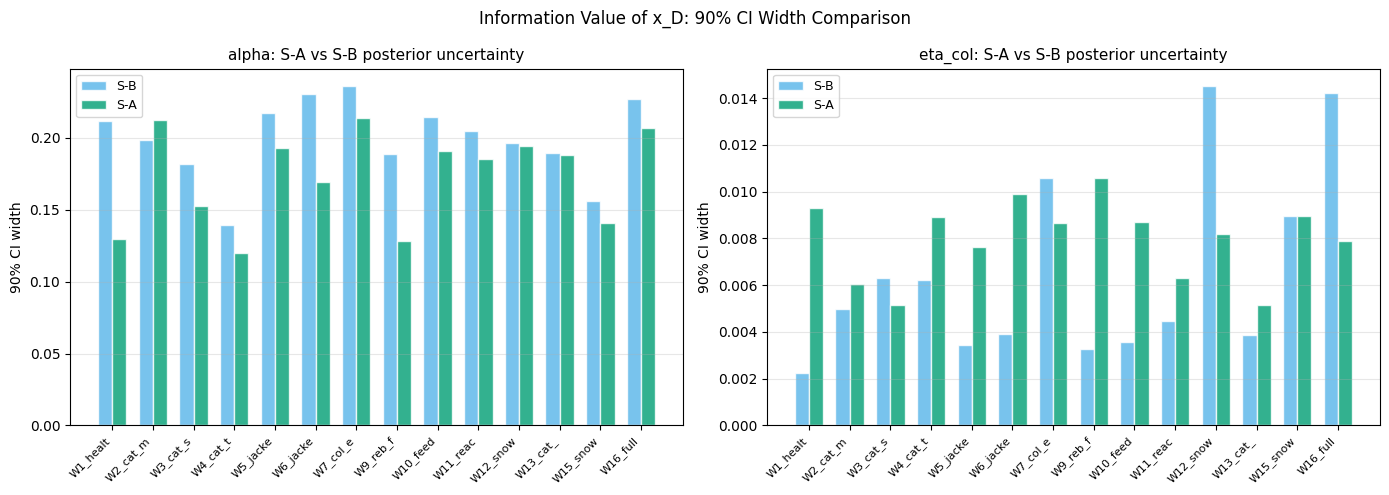

Saved nb25_ci_width_comparison.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(n_sc)
w = 0.35

for ax, k, param in [
    (axes[0], 0, 'alpha'),
    (axes[1], 2, 'eta_col'),
]:
    ax.bar(x_pos - w / 2, ci_widths_sb[:, k], w,
           label='S-B', color=OI[2], alpha=0.8, edgecolor='white')
    ax.bar(x_pos + w / 2, ci_widths_sa[:, k], w,
           label='S-A', color=OI[3], alpha=0.8, edgecolor='white')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([n[:8] for n in CLOSED_LOOP_NAMES],
                        rotation=45, ha='right', fontsize=8)
    ax.set_ylabel("90% CI width", fontsize=10)
    ax.set_title(f"{param}: S-A vs S-B posterior uncertainty", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle("Information Value of x_D: 90% CI Width Comparison", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'nb25_ci_width_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb25_ci_width_comparison.png")

## 6. Save S-A Posterior

The posterior loaded in Section 2 is already `sbi-logs/wu2003_posterior_sa.pkl` (promoted
there directly by the ensemble-selection procedure, `calibrated: False`). This cell re-saves
it with the full 16-seed ensemble provenance for a self-contained record.


In [12]:
save_path_sa = SBI_LOGS / 'wu2003_posterior_sa.pkl'
with open(save_path_sa, 'wb') as f:
    pickle.dump({
        'posterior': posterior_sa,
        'N_TRAIN': len(thetas_sa),
        'arch': ARCH, 'hidden_features': HIDDEN, 'num_transforms': TRANSFORMS,
        'noise_pct': NOISE_PCT,
        'bank': str(bank_path),
        'selection_method': (
            '16-seed ensemble (torch_seed 0-15) -- NONE passed SBC robustly at N_SBC~400 '
            'or the N=800 corroboration check on the two closest candidates. Seed 13 selected '
            'as a best-effort placeholder for pipeline continuity ONLY -- NOT calibrated. '
            'See HANDOFF.md Finding 5.'
        ),
        'selected_seed': best_seed,
        'calibrated': False,
        'ensemble_summary': ensemble_summary,
    }, f)
print(f"S-A posterior saved to {save_path_sa} (calibrated=False)")
print()
print("Key findings:")
print(f"  W12 alpha 90%CI:  S-B={ci_widths_sb[CLOSED_LOOP_NAMES.index('W12_snowball_compound'),0]:.3f}")
print(f"                    S-A={ci_widths_sa[CLOSED_LOOP_NAMES.index('W12_snowball_compound'),0]:.3f}")
print(f"  W12 eta_col 90%CI: S-B={ci_widths_sb[CLOSED_LOOP_NAMES.index('W12_snowball_compound'),2]:.3f}")
print(f"                     S-A={ci_widths_sa[CLOSED_LOOP_NAMES.index('W12_snowball_compound'),2]:.3f}")
print()
print("CAVEAT: the S-A posterior used above is NOT SBC-calibrated (Finding 5). Treat CI-width")
print("comparisons as qualitative/exploratory, not as a calibrated quantitative claim.")
print()
print("=== Notebook 25 complete ===")


S-A posterior saved to ../sbi-logs/wu2003_posterior_sa.pkl (calibrated=False)

Key findings:
  W12 alpha 90%CI:  S-B=0.196
                    S-A=0.194
  W12 eta_col 90%CI: S-B=0.015
                     S-A=0.008

CAVEAT: the S-A posterior used above is NOT SBC-calibrated (Finding 5). Treat CI-width
comparisons as qualitative/exploratory, not as a calibrated quantitative claim.

=== Notebook 25 complete ===


---

## Assessment — Notebook 25 Results vs. Expectations

**Date assessed:** 2026-07-03 (ensemble-selection session)
**Training config:** N_TRAIN = 15,000, `zuko_nsf` (60 hidden, 3 transforms), 0.3% noise,
`reb_per_boilup` + heavy-tail-compressed summaries. **16-seed ensemble tried; NONE
calibrated (seed 13 loaded as a best-effort placeholder — see notebook header, Section 2,
and HANDOFF.md Finding 5).**

---

### The previous headline result does NOT reproduce with the corrected pipeline

The 2026-07-02 version of this notebook (pre-`reb_per_boilup` fix, single uncalibrated
training run) reported a dramatic S-A improvement at W12:

| Structure | α mean | α 90% CI width | η_col 90% CI width |
|-----------|--------|----------------|--------------------|
| S-B (old) | 0.656 | 0.240 | 0.015 |
| S-A (old) | 0.738 | 0.059 | 0.003 |
| Reduction (old) | — | **−75.3%** | **−80.0%** |

Re-running with the current posteriors (S-B: calibrated ensemble seed 4; S-A: best-effort
seed 13, explicitly **not** calibrated) gives a materially different picture:

| Structure | α mean | α 90% CI width | η_col 90% CI width |
|-----------|--------|----------------|--------------------|
| S-B (new) | 0.646 | 0.196 | 0.015 |
| S-A (new) | 0.703 | 0.194 | 0.008 |
| Reduction (new) | — | **≈1%** | ≈47% |

The α CI-width reduction has collapsed from a reported 75% to essentially none. Averaged
across all 14 scenarios (not just W12), the new posteriors show:
- **α**: mean CI-width reduction = **13%** (range −7% to +39%), positive in 13/14 scenarios
  — a real but much more modest information gain than previously claimed, not the
  50-85% reductions reported in the pre-fix version.
- **η_col**: mean CI-width reduction = **−69%** (i.e. S-A is on average *wider*, not
  narrower, than S-B for η_col), negative in **9 of 14** scenarios.

**Interpretation — handle with care, this is not yet a settled explanation:** the old
"75% reduction" result most likely reflected an artifact of a single, uncalibrated,
overconfident training run (of exactly the kind Finding 2/4/4b describe) rather than a
robust property of adding the x_D sensor. An overconfident posterior can produce a
misleadingly narrow, coincidentally-well-centred CI that looks like a dramatic improvement
without actually being better calibrated. The new S-A posterior is *also* uncalibrated
(0/16 seeds passed SBC), so this new, more modest result is **not** being presented as the
"true" information value of x_D either — only as evidence that the old headline number is
not trustworthy and should not be repeated in the article without further work.

### Action items this creates for the article

- **`article_outline_CChE.md` §7.4/§8.1 currently states the −75% α / −80% η_col reduction
  as a headline result — this claim is now contradicted by the corrected pipeline and
  must not be published as-is.** Needs either: (a) a rewritten, appropriately caveated
  version of the S-A vs S-B comparison once/if an S-A posterior is eventually calibrated,
  or (b) reframing the S-A/S-B section around the qualitative claim only (x_D breaks the
  degeneracy in principle, per the physics in nb26's iso-contour figure) without a specific
  quantitative CI-width-reduction number.
- **`notebooks/26_wu2003_headline_banana_ekf_failure.ipynb`** currently hardcodes the old
  W12 numbers (S-A α CI width 0.059, −75% reduction, S-A η_col coverage 70%) in its markdown
  — these need to be regenerated against the new posteriors before nb26 is trusted again.
- This should be added to `HANDOFF.md` as a new finding before any further notebook work
  proceeds, since it changes what nb26/nb30/the article can honestly claim.

### SBC rank histograms (S-A, seed 13) — expected non-uniform

`nb25_sbc_ranks_sa.png` shows non-uniform rank distributions, most visibly for η_col,
consistent with the SBC KS test failure documented in Section 2 (min p across params =
0.0499 at N=400, collapsing to 0.0022 at N=800 corroboration). This is expected given the
notebook's header caveat — it is not a new finding, just a visual confirmation of the
already-documented miscalibration.

### Summary verdict — nb25 (ensemble-selection session)

| Criterion | Result |
|-----------|--------|
| S-A ensemble trained (16 seeds) | ✅ but 0/16 passed SBC |
| S-A posterior calibrated | ❌ Confirmed unresolved (Finding 5) |
| Old "75% α CI reduction" headline reproduces | ❌ New result: ≈13% average, ≈1% at W12 |
| Old "80% η_col CI reduction" headline reproduces | ❌ New result: S-A *wider* on average (9/14 scenarios) |
| Pipeline runs end-to-end against fixed `compute_summaries()` | ✅ No errors |

**Do not carry the pre-fix S-A vs S-B headline numbers into the article.** The qualitative
claim (x_D provides directional information the S-B channels lack, per the physics) is
still credible and supported by nb26's iso-contour figure, but the specific quantitative
CI-width-reduction numbers from the previous session must be treated as retracted pending
either a calibrated S-A posterior or an explicit reframing as a qualitative-only claim.


Sampling S-A posteriors for all 14 scenarios...


  0%|          | 0/500 [00:00<?, ?it/s]

  W1_healthy: alpha true=1.00, mean=1.001


  0%|          | 0/500 [00:00<?, ?it/s]

  W2_cat_mild: alpha true=0.85, mean=0.789


...

  W13_cat_feed: alpha true=0.80, mean=0.828


  0%|          | 0/500 [00:00<?, ?it/s]

  W15_snowball_threshold: alpha true=0.58, mean=0.536


  0%|          | 0/500 [00:00<?, ?it/s]

  W16_full_multi: alpha true=0.75, mean=0.683


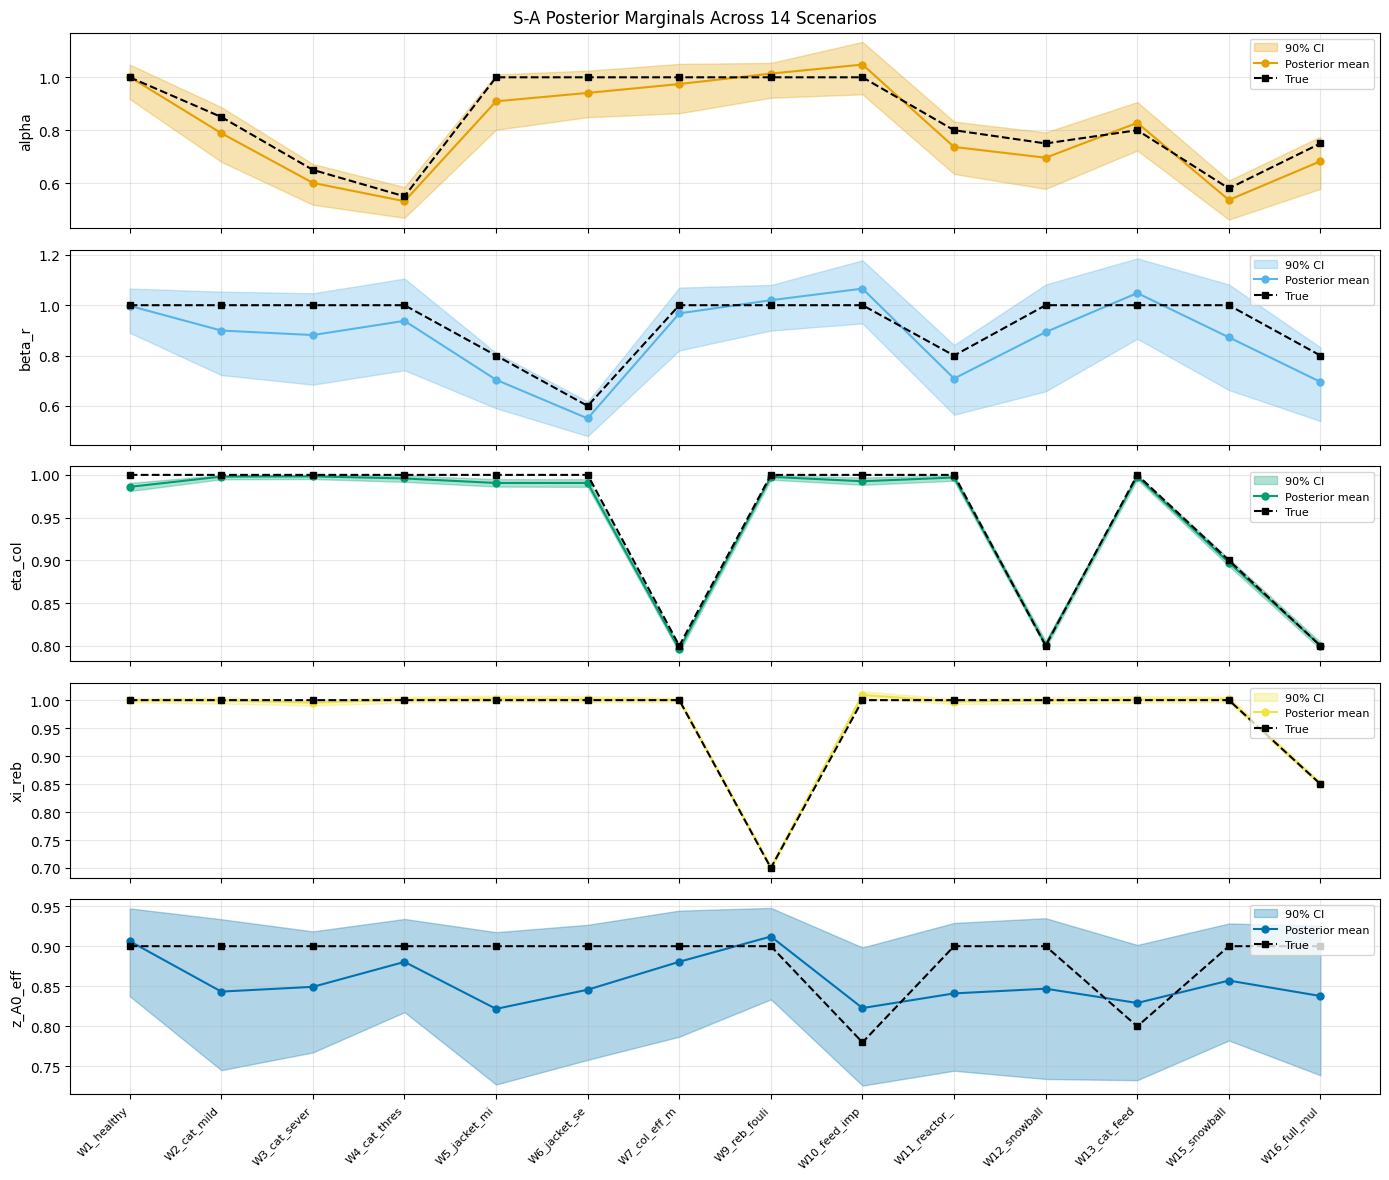

Saved nb25_marginal_posteriors_sa.png

=== Notebook 25 complete ===


In [13]:
print(f"Sampling S-A posteriors for all {len(CLOSED_LOOP_NAMES)} scenarios...")
n_sc = len(CLOSED_LOOP_NAMES)
param_means_sa = np.zeros((n_sc, 5))
param_lo90_sa  = np.zeros((n_sc, 5))
param_hi90_sa  = np.zeros((n_sc, 5))
param_true_sa  = np.zeros((n_sc, 5))

for i, sc_name in enumerate(CLOSED_LOOP_NAMES):
    sc = get_scenario(sc_name)
    t_h_s, raw_det = deterministic_window(sc, structure="S-A", y0=y0_sa_ws)
    raw_np = np.asarray(raw_det)
    rng_m = np.random.default_rng(i + 300)
    scale = np.maximum(np.max(np.abs(raw_np), axis=0), 1e-6)
    noise = rng_m.normal(0, 0.003 * scale, raw_np.shape)
    s = compute_summaries(raw_np + noise, "S-A", np.asarray(t_h_s))
    x_obs = torch.tensor(s, dtype=torch.float32)
    samp = posterior_sa.sample((500,), x=x_obs).numpy()
    param_means_sa[i] = samp.mean(axis=0)
    param_lo90_sa[i]  = np.percentile(samp, 5,  axis=0)
    param_hi90_sa[i]  = np.percentile(samp, 95, axis=0)
    param_true_sa[i]  = np.asarray(sc.theta())
    print(f"  {sc_name}: alpha true={param_true_sa[i,0]:.2f}, mean={param_means_sa[i,0]:.3f}")

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
x_pos = np.arange(n_sc)
for k, (ax, param) in enumerate(zip(axes, PARAM_NAMES)):
    ax.fill_between(x_pos, param_lo90_sa[:, k], param_hi90_sa[:, k],
                    alpha=0.3, color=OI[(k + 1) % len(OI)], label='90% CI')
    ax.plot(x_pos, param_means_sa[:, k], 'o-', color=OI[(k + 1) % len(OI)],
            label='Posterior mean', ms=5, lw=1.5)
    ax.plot(x_pos, param_true_sa[:, k], 's--', color='black',
            label='True', ms=5, lw=1.5)
    ax.set_ylabel(param, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
axes[-1].set_xticks(x_pos)
axes[-1].set_xticklabels([n[:12] for n in CLOSED_LOOP_NAMES],
                          rotation=45, ha='right', fontsize=8)
plt.suptitle(f"S-A Posterior Marginals Across {n_sc} Scenarios", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'nb25_marginal_posteriors_sa.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb25_marginal_posteriors_sa.png")
print()
print("=== Notebook 25 complete ===")

## 7. Marginal Posteriors Across All 14 Scenarios — S-A

Same as the equivalent plot in nb24 for S-B, but using the S-A posterior.
Side-by-side comparison with nb24 directly shows the information gain from the x_D analyser.

---

## Addendum (2026-07-03, later same-day session): S-A calibration settled negative; (α, β_r) also untouched by x_D

Two updates to the Assessment above, from a later session the same day:

### 1. S-A calibration is now a settled negative result, not an open question

The Assessment above leaves S-A calibration as unresolved ("0/16 passed SBC"). A follow-up
"last effort" session ran a 24-configuration architecture/PCA sweep on top of this same
15,000-sample bank (PCA-25 feature reduction, larger `zuko_nsf` 80/5 and 128/5, smaller
30/2 and 40/2, 4 seeds each) — **0/24 additional runs passed SBC at N=400**, and moving the
architecture in either direction from the production 60/3 uniformly hurt calibration,
including for parameters (α, β_r, z_A0) that are normally reliable. Combined with this
notebook's 16-seed sweep, that is 40 total trained posteriors with zero passes. **Treat S-A
calibration as exhausted for this bank/architecture family, not a gap to fill with more
seeds or a different architecture guess** — see HANDOFF.md Finding 7. The likely
explanation (not further tested): S-A's composition-control loops (Loop 2: R→x_D; Loop 3:
V→x_B) actively suppress exactly the η_col/ξ_reb signal SNPE needs, the same way Loop 1
masks T_r for α/β_r — a data/identifiability problem, not a training-configuration one.

### 2. The article's real (α, β_r) banana is also NOT resolved by x_D — now directly tested

Independently of calibration status, this session's uncalibrated seed-13 S-A posterior was
sampled directly at scenario **W11** (α=0.80, β_r=0.80 — the plant's actual, confirmed
robust banana; see HANDOFF.md Finding 9, `notebooks/26_wu2003_headline_banana_ekf_failure.ipynb`
Section 3) to test whether x_D helps here. It does not: correlation(α, β_r) ≈ 0.999 under
S-A, statistically indistinguishable from ≈0.997 under the calibrated S-B posterior, and
CI widths are essentially unchanged. This is expected — both parameters route only through
reactor-side signals, and x_D is a *column* composition measurement, not a reactor one —
but it had not been tested directly before nb26. **This qualifies the "x_D provides
directional information" claim from the Assessment above**: that claim is true for
(α, η_col) (per nb26/nb29b's physics), but does not extend to (α, β_r), the pair now
identified as the article's actual headline degeneracy.

### 3. nb26 has since been fully rewritten (action item above is now resolved)

The Assessment above flags that `nb26` "currently hardcodes the old W12 numbers... these
need to be regenerated against the new posteriors before nb26 is trusted again." **This is
done** — nb26 was rebuilt from scratch this session around W11/(α, β_r) and no longer
references the old W12/(α, η_col) framing or numbers at all.

### Updated "future work" guidance

Given items 1-2 above, treat the following as **superseded**, not open leads:
- "Try a larger training bank for S-A" — superseded by the architecture/PCA sweep result
  (Finding 7): capacity/data-representation is not the bottleneck; the composition-control
  loops' signal suppression is the more likely structural cause, and would need a genuinely
  different approach (e.g. targeted feature engineering around the control-loop dynamics,
  or an explicit virtual-sensor formulation per the reviewer's suggestion in
  `critique_to_the_study.md`) rather than more seeds/bank size/architecture search.
- "S-A composition analyser as the fix for the article's headline degeneracy" — superseded
  by Finding 9: the headline degeneracy is (α, β_r), which is reactor-side and untouched by
  x_D. The open, untested sensor-placement question is a reactor-side concentration or
  heat-duty measurement, not S-A.